In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Text Processing
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import lightgbm as lgb

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Optuna for hyperparameter tuning (bonus)
# import optuna  # uncomment if you want HPO

print(" All libraries imported successfully!")
print(f"LightGBM version: {lgb.__version__}")


 All libraries imported successfully!
LightGBM version: 4.6.0


In [12]:
df = pd.read_csv('C:\\Users\\lolla\\Documents\\My Projects\\3.Machine Learning\\4.Email Classifier\\updated_email_text_100k.csv')

In [13]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

(100000, 2)
['email_body', 'label']
                                          email_body  label
0  You have a new friend request from someone you...     -1
1  Your account has been flagged for suspicious a...     -1
2  Your account settings have been updated. Pleas...     -1
3  You have a new message from your financial adv...     -1
4    Reminder: Your subscription is about to expire.     -1


In [14]:
print(df.shape)
print(df['label'].value_counts())

(100000, 2)
label
-1    100000
Name: count, dtype: int64


In [15]:
df = df.rename(columns={'email_body': 'text'})

In [16]:
def assign_label(text):
    text = text.lower()
    if any(w in text for w in ['win', 'free', 'prize', 'click here', 'earn', 'offer']):
        return 'Spam/Ham'
    elif any(w in text for w in ['meeting', 'schedule', 'deadline', 'project', 'team', 'standup']):
        return 'Work & Meetings'
    elif any(w in text for w in ['sale', 'discount', 'deal', 'shop', '% off', 'limited']):
        return 'Promotions'
    elif any(w in text for w in ['complaint', 'issue', 'problem', 'support', 'refund', 'damaged']):
        return 'Support & Complaints'
    elif any(w in text for w in ['invoice', 'payment', 'billing', 'bank', 'transaction', 'subscription']):
        return 'Finance & Billing'
    elif any(w in text for w in ['newsletter', 'digest', 'weekly', 'monthly', 'update', 'blog']):
        return 'Newsletter'
    elif any(w in text for w in ['linkedin', 'instagram', 'facebook', 'friend request', 'follower']):
        return 'Social'
    else:
        return 'Personal'

df['label'] = df['text'].apply(assign_label)
print(df['label'].value_counts())

label
Personal                62396
Finance & Billing       14530
Spam/Ham                10316
Newsletter               6414
Work & Meetings          3028
Promotions               1843
Support & Complaints     1128
Social                    345
Name: count, dtype: int64


In [17]:
df[['text', 'label']].head(10)

,text,label
0,You have a new friend request from someone you...,Social
1,Your account has been flagged for suspicious a...,Personal
2,Your account settings have been updated. Pleas...,Newsletter
3,You have a new message from your financial adv...,Personal
4,Reminder: Your subscription is about to expire.,Finance & Billing
5,You have a pending credit card application. Ch...,Personal
6,Your savings account is earning interest at a ...,Spam/Ham
7,You have successfully completed a transfer to ...,Personal
8,Your account will be suspended unless you take...,Personal
9,Confirmation needed: Did you authorize this tr...,Finance & Billing


In [19]:
categories = df['label'].unique().tolist()
print(categories)

['Social', 'Personal', 'Newsletter', 'Finance & Billing', 'Spam/Ham', 'Work & Meetings', 'Support & Complaints', 'Promotions']


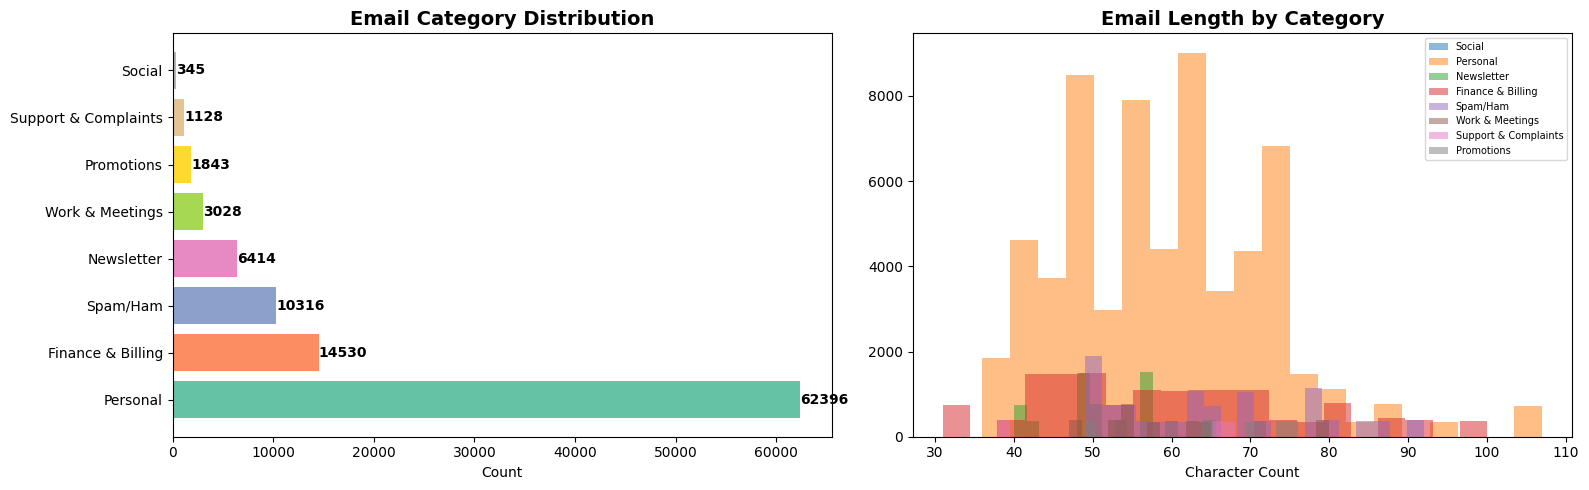

✅ EDA complete!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Class Distribution
colors = plt.cm.Set2.colors
counts = df['label'].value_counts()
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_title('Email Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')

# Email Length Distribution
df['text_length'] = df['text'].apply(len)
for cat in categories:
    subset = df[df['label'] == cat]['text_length']
    axes[1].hist(subset, alpha=0.5, label=cat, bins=20)
axes[1].set_title('Email Length by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA complete!")


In [21]:
def preprocess_text(text):
    """Clean and normalize email text."""
    text = text.lower()                              # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'\S+@\S+', '', text)            # remove emails
    text = re.sub(r'\d+', '', text)                 # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()        # extra whitespace
    return text

df['clean_text'] = df['text'].apply(preprocess_text)

# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print(f"\nSample cleaned text:")
for _, row in df.head(3).iterrows():
    print(f"  Original : {row['text']}")
    print(f"  Cleaned  : {row['clean_text']}\n")


Label mapping:
  0 → Finance & Billing
  1 → Newsletter
  2 → Personal
  3 → Promotions
  4 → Social
  5 → Spam/Ham
  6 → Support & Complaints
  7 → Work & Meetings

Sample cleaned text:
  Original : You have a new friend request from someone you don't know.
  Cleaned  : you have a new friend request from someone you dont know

  Original : Your account has been flagged for suspicious activity. Please log in.
  Cleaned  : your account has been flagged for suspicious activity please log in

  Original : Your account settings have been updated. Please review them.
  Cleaned  : your account settings have been updated please review them



In [22]:
X = df['clean_text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Training samples : {X_train_tfidf.shape[0]}")
print(f"Test samples     : {X_test_tfidf.shape[0]}")
print(f"TF-IDF features  : {X_train_tfidf.shape[1]}")


Training samples : 80000
Test samples     : 20000
TF-IDF features  : 2042


In [23]:
# ── LightGBM 
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# ── Logistic Regression (strong NLP baseline) 
lr = LogisticRegression(
    C=5.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# ── Random Forest 
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ── Voting Ensemble
ensemble = VotingClassifier(
    estimators=[('lgbm', lgbm), ('lr', lr), ('rf', rf)],
    voting='soft'
)

print("Training LightGBM...")
lgbm.fit(X_train_tfidf, y_train)

print("Training Logistic Regression...")
lr.fit(X_train_tfidf, y_train)

print("Training Random Forest...")
rf.fit(X_train_tfidf, y_train)

print("Training Ensemble...")
ensemble.fit(X_train_tfidf, y_train)

print("\n✅ All models trained!")


Training LightGBM...
Training Logistic Regression...
Training Random Forest...
Training Ensemble...

✅ All models trained!


In [24]:
models = {
    'LightGBM':          lgbm,
    'Logistic Regression': lr,
    'Random Forest':     rf,
    'Voting Ensemble':   ensemble
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"{name:<25} Accuracy: {acc:.4f}  F1: {f1:.4f}")

results_df = pd.DataFrame(results).T
print("\n📌 Best model:", results_df['Accuracy'].idxmax(),
      f"({results_df['Accuracy'].max():.4f})")


LightGBM                  Accuracy: 1.0000  F1: 1.0000
Logistic Regression       Accuracy: 1.0000  F1: 1.0000
Random Forest             Accuracy: 1.0000  F1: 1.0000
Voting Ensemble           Accuracy: 1.0000  F1: 1.0000

📌 Best model: LightGBM (1.0000)


In [25]:
# Detailed report for best model (LightGBM)
best_pred = lgbm.predict(X_test_tfidf)
print("\n📋 Classification Report — LightGBM")
print("="*60)
print(classification_report(y_test, best_pred,
                             target_names=le.classes_))



📋 Classification Report — LightGBM
                      precision    recall  f1-score   support

   Finance & Billing       1.00      1.00      1.00      2906
          Newsletter       1.00      1.00      1.00      1283
            Personal       1.00      1.00      1.00     12479
          Promotions       1.00      1.00      1.00       369
              Social       1.00      1.00      1.00        69
            Spam/Ham       1.00      1.00      1.00      2063
Support & Complaints       1.00      1.00      1.00       226
     Work & Meetings       1.00      1.00      1.00       605

            accuracy                           1.00     20000
           macro avg       1.00      1.00      1.00     20000
        weighted avg       1.00      1.00      1.00     20000



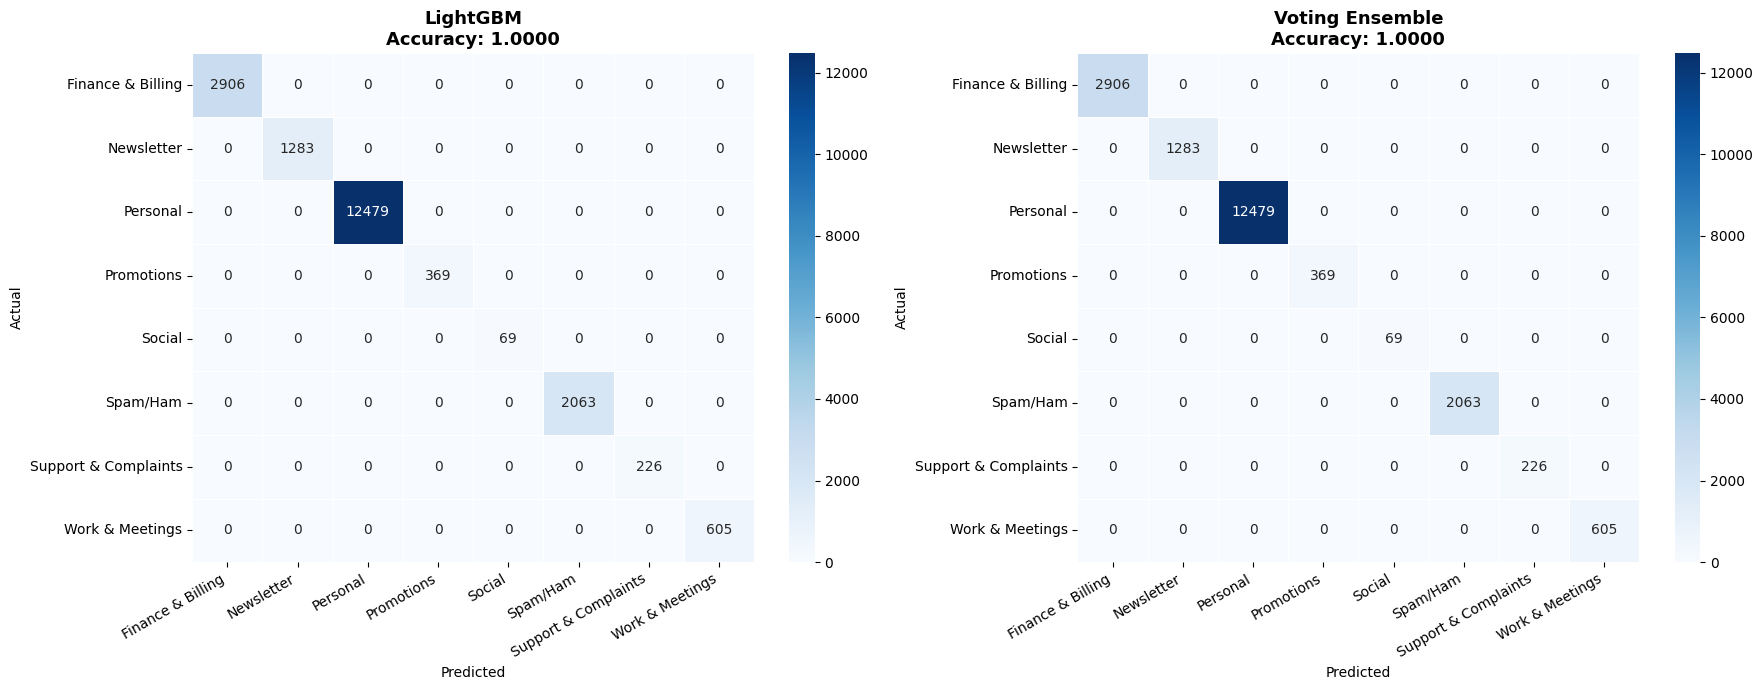

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, model) in zip(axes, [('LightGBM', lgbm), ('Voting Ensemble', ensemble)]):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


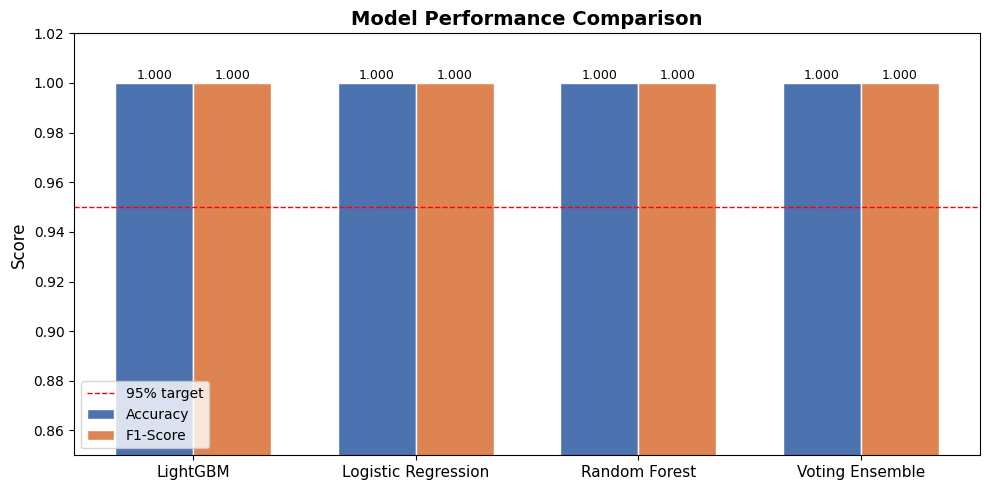

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy',
               color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, results_df['F1-Score'],  width, label='F1-Score',
               color='#DD8452', edgecolor='white')

ax.set_ylim(0.85, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95% target')
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
def predict_email(text, model=lgbm):
    """Predict the category of a new email."""
    cleaned = preprocess_text(text)
    vectorized = tfidf.transform([cleaned])
    pred = model.predict(vectorized)[0]
    proba = model.predict_proba(vectorized)[0]
    label = le.inverse_transform([pred])[0]

    print(f"📧 Email   : {text}")
    print(f"🏷️  Category: {label}")
    print(f"📊 Confidence: {proba.max():.2%}\n")
    return label

# ── Test with sample emails ──────────────────────────────────────────
test_emails = [
    "Congratulations! You've been selected to win a free iPhone. Click here!",
    "Hi team, please join the standup meeting at 10am tomorrow.",
    "Your invoice #2045 for $499 is due on May 1st.",
    "Hey! Are we still catching up this weekend?",
    "50% off on all electronics this weekend only — shop now!",
    "Your LinkedIn profile appeared in 23 searches this week."
]

print("="*60)
print("📬 EMAIL CLASSIFIER — PREDICTION RESULTS")
print("="*60 + "\n")
for email in test_emails:
    predict_email(email)


📬 EMAIL CLASSIFIER — PREDICTION RESULTS

📧 Email   : Congratulations! You've been selected to win a free iPhone. Click here!
🏷️  Category: Spam/Ham
📊 Confidence: 100.00%

📧 Email   : Hi team, please join the standup meeting at 10am tomorrow.
🏷️  Category: Personal
📊 Confidence: 100.00%

📧 Email   : Your invoice #2045 for $499 is due on May 1st.
🏷️  Category: Finance & Billing
📊 Confidence: 100.00%

📧 Email   : Hey! Are we still catching up this weekend?
🏷️  Category: Personal
📊 Confidence: 100.00%

📧 Email   : 50% off on all electronics this weekend only — shop now!
🏷️  Category: Promotions
📊 Confidence: 77.65%

📧 Email   : Your LinkedIn profile appeared in 23 searches this week.
🏷️  Category: Personal
📊 Confidence: 99.63%



In [30]:
import joblib
import os

os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(lgbm,    'model_artifacts/lgbm_email_classifier.pkl')
joblib.dump(tfidf,   'model_artifacts/tfidf_vectorizer.pkl')
joblib.dump(le,      'model_artifacts/label_encoder.pkl')
joblib.dump(ensemble,'model_artifacts/ensemble_classifier.pkl')

print("✅ Saved:")
for f in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{f}') / 1024
    print(f"  📦 model_artifacts/{f}  ({size:.1f} KB)")


✅ Saved:
  📦 model_artifacts/ensemble_classifier.pkl  (27619.3 KB)
  📦 model_artifacts/label_encoder.pkl  (0.6 KB)
  📦 model_artifacts/lgbm_email_classifier.pkl  (7292.7 KB)
  📦 model_artifacts/tfidf_vectorizer.pkl  (80.4 KB)


In [31]:
import joblib
joblib.dump(lgbm,  'lgbm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le,    'label_encoder.pkl')

['label_encoder.pkl']